# News classification Using BERT 
新聞分類使用bert-base-chinese神經網路

11 Categories

Tesla T4 GPU: 1hr 38mins

    Epoch	Training Loss	Validation Loss	Accuracy	F1	Precision	Recall
    1	No log	0.441262	0.888464	0.888464	0.888464	0.888464
    2	1.311100	0.313443	0.903743	0.903743	0.903743	0.903743
    3	0.354700	0.282272	0.911383	0.911383	0.911383	0.911383
    4	0.237500	0.261624	0.918258	0.918258	0.918258	0.918258
    5	0.172200	0.277857	0.915202	0.915202	0.915202	0.915202
    6	0.121100	0.297056	0.915584	0.915584	0.915584	0.915584

    ==> Best saved model with the lowest validation_loss:
    4	0.237500	0.261624	0.918258	0.918258	0.918258	0.918258

# BERT

<img src="https://cdn.learnwoo.com/wp-content/uploads/2021/09/Google-BERT-696x392.png">    
<img src="https://riccardo-cantini.netlify.app/post/bert_text_classification/featured_hua8bf7d9829a3c2e45f4e3633adf00c19_474726_720x0_resize_lanczos_2.png">
   
    What is BERT?
    Bidirectional Encoder Representations from Transformers (BERT) is a Natural Language Processing Model proposed by Google Research in 2018. It is based on a multi-layer bidirectional Transformer, pre-trained on two unsupervised tasks using a large crossdomain corpus:

    * Masked Language Modeling (MLM): 15% of the words in each sequence are replaced with a [MASK] token. The model then attempts to predict the masked words, based on the context provided by the non-masked ones.
    * Next Sentence Prediction (NSP): the model receives pairs of sentences as input and learns to predict if the second sentence is the subsequent sentence in the original document.
    
    BERT is deeply bidirectional, which means that it can learn the context of a word based on all the information contained in the input sequence, joinlty considering previous and subsequent tokens. In fact, the use of MLM objective enables the representation to fuse the left and right contexts, allowing the pre-training of a deep bidirectional language representation model. This is a key difference comparing to previous language representation models like OpenAI GPT, which uses a unidirectional (left-to-right) language model, or ELMo, which uses a shallow concatenation of independently trained left-to-right and right-to-left language models. BERT outperformed many task-specific architectures, advancing the state of the art in a wide range of Natural Language Processing tasks, such as textual entailment, text classification and question answering.

    For further details, you might want to read the original BERT paper.

    什麼是 BERT？
    模型來自 Transformers 的雙向編碼器表示 (BERT)是 Google Research 在 2018 年提出的自然語言處理模型。它基於多層雙向 Transformer，使用大型跨域語料庫對兩個無監督任務進行預訓練。

    大量的訓練數據

        33 億字的海量數據集

        BERT 專門針對 Wikipedia（約 2.5B 字）和 Google 的 BooksCorpus（約 8 億字）進行了訓練。這些大型信息數據集不僅有助於 BERT 深入了解語言，還有助於了解我們的世界！🚀

        在這麼大的數據集上訓練需要很長時間。BERT 的訓練得益於新穎的 Transformer 架構，並通過使用 TPU（張量處理單元——谷歌專為大型 ML 模型構建的定制電路）加快了訓練速度。— 64 個 TPU 在 4 天的時間裡訓練了 BERT。


    * 掩碼語言建模 (MLM)：每個序列中 15% 的單詞被替換為一個[MASK]標記。然後，該模型嘗試根據非蒙面詞提供的上下文來預測蒙面詞。
    * Next Sentence Prediction (NSP)：模型接收成對的句子作為輸入，並學習預測第二個句子是否是原始文檔中的後續句子。
    
    BERT 是深度雙向的，這意味著它可以根據輸入序列中包含的所有信息來學習單詞的上下文，同時考慮前後標記。事實上，MLM 目標的使用使表示能夠融合左右上下文，從而允許對深度雙向語言表示模型進行預訓練。這是與以前的語言表示模型（如OpenAI GPT ）相比的關鍵區別，OpenAI GPT使用單向（從左到右）語言模型或 ELMo，它使用獨立訓練的從左到右和從右到左語言模型的淺連接。BERT 優於許多特定於任務的架構，在廣泛的自然語言處理任務（例如文本蘊涵、文本分類和問答）中提升了最新技術水平。

    有關更多詳細信息，您可能需要閱讀原始BERT 論文。
    
    source: https://riccardo-cantini.netlify.app/post/bert_text_classification/



# Transformers變形金剛(變壓器)模型

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2019/06/Screenshot-from-2019-06-17-19-53-10.png">

Bert and GPT are parts of Transformer

<img src="https://heidloff.net/assets/img/2023/02/transformers.png" width="800">

Encoders and Decoders
As mentioned, there are encoders and decoders. BERT uses encoders only, GTP uses decoders only. Both options understand language including syntax and semantics. Especially the next generation of large language models like GPT with billions of parameters do this very well.

The two models focus on different scenarios. However, since the field of foundation models is evolving, the differentiation is often fuzzier.

BERT (encoder): classification (e.g., sentiment), questions and answers, summarization, named entity recognition
GPT (decoder): translation, generation (e.g., stories)
The outputs of the core models are different:

BERT (encoder): Embeddings representing words with attention information in a certain context
GPT (decoder): Next words with probabilities
Both models are pretrained and can be reused without intensive training. Some of them are available as open source and can be downloaded from communities like Hugging Face, others are commercial. Reuse is important, since trainings are often very resource intensive and expensive which few companies can afford.

The pretrained models can be extended and customized for different domains and specific tasks. Layers can sometimes be reused without modifications and more layers are added on top. If layers need to be modified, the new training is more expensive. The technique to customize these models is called Transfer Learning, since the same generic model can easily be transferred to other domains.

[Source](https://heidloff.net/article/foundation-models-transformers-bert-and-gpt/)

# Transfor Learning (遷移學習), Finetune from the pretrained model (微調一個預訓練模型)

## 預訓練

克漏字填空（Mask Language Model）
Masked Language Model（MLM）
句子丟進去模型進行訓練，會把一些字詞遮蓋(Mask)起來，讓模型去預測被遮蓋起來的字詞是什麼。

下文預測（Next Sentence Prediction）
Next Sentence Prediciton (NSP)。預測下一個可能的句子是什麼。(為了要解決文本生成，或是 QA 的任務)

<img src='https://leemeng.tw/images/bert/bert-pretrain-tasks.jpg' width='800'>

# 微調
將一個大型的預訓練模型拿來加以運用在解決其他領域的問題上，加上自己的資料再加以微調預訓練模型，變成一個可以解決你的問題的模型，可以節省成本。

例如:將Bert模型施以在訓練，使用自己準備的情緒語料，變成一個情緒分類器，這就是在做微調的工作。這樣就是一種遷移學習。

單一句子分類、單一句子標註、成對句子預測，以及問答任務。


來源:台大李宏毅老師講義

<img src='https://leemeng.tw/images/bert/bert_fine_tuning_tasks.jpg' width='800'>

# BERT Input and Output (輸入與輸出)

BERT的輸出有兩項:last_hidden_state, pooler_output



### Bert input and output

    Bert input and output is as follows:

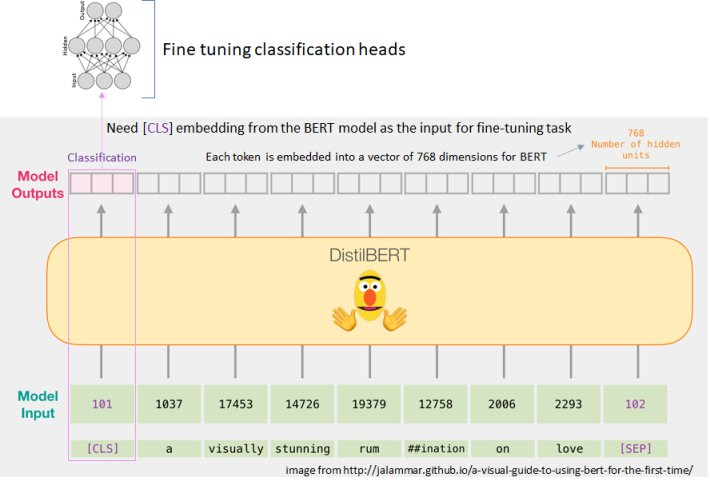


# Supervised Learning for text classification

A text classification procedure is composed of following components:

Training text: It is the input text through which our supervised learning model is able to learn and predict the required class.

Feature Vector: A feature vector is a vector that contains information describing the characteristics of the input data.

Labels: These are the predefined categories/classes that our model will predict.

ML Algorithm: It is the algorithm through which our model is able to deal with text classification (In our case : CNN, RNN)


Predictive Model: A model trained on the dataset can perform label predictions.

![](https://miro.medium.com/max/1270/1*xuvsmqxSjgvqJKs1j_Bo8w.png)

## Dataset for Model Training, Validation and Testing

Slicing a single data set into three subsets.

![](https://cdn-images-1.medium.com/freeze/max/1000/1*ZiYvylk60EY2XG7ck1lqJA.png?q=20)

## Main steps for training machine learning models

# Word Embedding

    Pretrained Embedding:
    https://keras-cn.readthedocs.io/en/latest/blog/word_embedding/
    http://ben.bolte.cc/blog/2016/gensim.html
    https://gist.github.com/codekansas/15b3c2a2e9bc7a3c345138a32e029969
    https://blog.keras.io/using-pre-trained-word-embeddings-in-a-keras-model.html


<img src="images/word_embedding_graph.png" width="600">

# Various Deep Learning Model

<img src='https://orbograph.com/wp-content/uploads/2019/01/DeepLearn.png'>

<img src='https://miro.medium.com/max/2000/1*cuTSPlTq0a_327iTPJyD-Q.png' width=700>

### Encoder-Decoder Transformers



<img src='https://miro.medium.com/v2/resize:fit:1400/format:webp/1*vrSX_Ku3EmGPyqF_E-2_Vg.png'>

### Attension Layer
<img src='https://miro.medium.com/v2/resize:fit:640/format:webp/1*aTLu4HxVUzEOIZTLHmOktw.png'>

# Colab GPU
## 設定執行階段 變更執行階段類型 硬體加速器  選取GPU  


In [7]:
!nvidia-smi

Wed Apr 23 08:38:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090      WDDM  |   00000000:01:00.0 Off |                  Off |
|  0%   35C    P8             16W /  450W |       0MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# 列出GPU與CPU資源
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12144688931418828727
xla_global_id: -1
]


In [9]:
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

## Ubuntu版本資訊

In [10]:
#!lsb_release -a

# Insatll packages


        transformers: For model handling.
        peft: For LoRA integration.
        datasets: For dataset handling.
        accelerate: For distributed training.
        bitsandbytes: For memory-efficient training (optional but useful for Qwen).

In [ ]:
#!pip install transformers peft datasets accelerate bitsandbytes

In [ ]:
pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 8.1 MB/s eta 0:00:00


# 掛載雲端硬碟

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# 切換工作目錄到雲端硬碟目錄下(取用資料比較方便，可以用相對路徑)

In [13]:
# pwd

In [14]:
#你要改成你自己雲端硬碟目錄的路徑，有複製路徑的功能可以使用，不要用鍵盤輸入!
# cd 前面一行不要加上說明文字，否則colab的cd會認不得指令

In [15]:
# cd to_your_folder

In [ ]:
cd /content/drive/MyDrive/Colab Notebooks

In [17]:
ls -l

 �Ϻа� G �����ϺЬO dr.chenglung@gmail.com - Goog...
 �ϺаϧǸ�:  1983-1116

 g:\�ڪ����ݵw��\10-08-�оǤ���2\10-30-�Ӥh�Z-�ֱ����R-��z��\w13-2-�y���ҫ��P������\3-�s�D����\w15-2-Bert news classification using Transformers Trainer\Step 2-model training ���ؿ�



�䤣���ɮ�


In [1]:
import numpy as np
import pandas as pd

# Load Huggingface transformers
from transformers import TrainingArguments, Trainer
from transformers import BertTokenizer, BertTokenizerFast, BertForSequenceClassification
import torch
import evaluate
import datasets

## GPU Device

In [2]:
# Setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


# Read data

中央社新聞2.6萬篇

In [3]:
file_name= './news_dataset_preprocessed_for_django.csv'
df = pd.read_csv(file_name, sep='|')

In [4]:
df.head(1)

,item_id,title,category,content,link,date,photo_link,tokens_v2,top_keys_freq,summary,sentiment
0,aipl_20220124_1001,殲16D首擾台 專家示警：國軍應強化電子作戰,政治,中共殲16D新型電戰機今天首次擾台，學者及退將分析，殲16D可能已量產並進行實戰化運用，國軍...,https://www.cna.com.tw/news/aipl/202201240357....,2022-01-24,https://imgcdn.cna.com.tw/www/WebPhotos/200/20...,"['中共', '新型', '電戰機', '學者', '退將', '分析', '量產', '進...","[('中共', 7), ('台灣', 7), ('電子', 6), ('美軍', 6), (...","['其中殲16D新型電戰機為首次現蹤', '中共殲16D新型電戰機今天首次擾台', '13架...",0.96


In [5]:
df.shape

(26179, 11)

In [6]:
df.groupby('category').size()

category
兩岸    1555
國際    6228
娛樂     639
政治    2988
文化     666
生活    5920
產經    2541
社會    2055
科技     171
證卷    1793
運動    1623
dtype: int64

# Convert the format of y

Convert the format of y from int to LongTensor

## Convert label using one-hot representation 輸出資料格式one-hot轉換
    
    轉成用2個節點表達兩類
    類別0: [1 0]  
    類別1: [0 1]  


    如果是3個類別用3個節點表之:
    類別0: [1 0 0]  
    類別1: [0 1 0]  
    類別2: [0 0 1]

負面情緒Negative 0 --> [1 0]

正面情緒Positive 1 --> [0 1]

## Easy Represention 0,1,2... (內部會自動轉換為one-hot)

    負面情緒Negative 0 --> [0]

    正面情緒Positive 1 --> [1]

    如果是3個類別
    中立情緒 Neutral 2 --> [2]


## label <--> id

## Convert category name ('政治','科技','運動',...) into number (0,1,2,...)

In [7]:
news_categories=['政治','科技','運動','證卷','產經','娛樂','生活','國際','社會','文化','兩岸']

In [8]:
cate2idx = { cate : i for i, cate in enumerate(news_categories)}

In [9]:
cate2idx

{'政治': 0,
 '科技': 1,
 '運動': 2,
 '證卷': 3,
 '產經': 4,
 '娛樂': 5,
 '生活': 6,
 '國際': 7,
 '社會': 8,
 '文化': 9,
 '兩岸': 10}

In [10]:
idx2cate = { i : cate for i, cate in enumerate(news_categories)}

In [11]:
idx2cate

{0: '政治',
 1: '科技',
 2: '運動',
 3: '證卷',
 4: '產經',
 5: '娛樂',
 6: '生活',
 7: '國際',
 8: '社會',
 9: '文化',
 10: '兩岸'}

In [12]:
# get labes
labels = [cate2idx[cate] for cate in df['category']]

In [13]:
len(labels) 

26179

In [14]:
labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 6,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,
 7,


In [ ]:
df['label']=labels
#新增Label欄位

In [16]:
df.head(1)

,item_id,title,category,content,link,date,photo_link,tokens_v2,top_keys_freq,summary,sentiment,label
0,aipl_20220124_1001,殲16D首擾台 專家示警：國軍應強化電子作戰,政治,中共殲16D新型電戰機今天首次擾台，學者及退將分析，殲16D可能已量產並進行實戰化運用，國軍...,https://www.cna.com.tw/news/aipl/202201240357....,2022-01-24,https://imgcdn.cna.com.tw/www/WebPhotos/200/20...,"['中共', '新型', '電戰機', '學者', '退將', '分析', '量產', '進...","[('中共', 7), ('台灣', 7), ('電子', 6), ('美軍', 6), (...","['其中殲16D新型電戰機為首次現蹤', '中共殲16D新型電戰機今天首次擾台', '13架...",0.96,0


# Sample some examples for demonstration

In [17]:
# Sample if you want to reduce the dataset size
# df = df.sample(5000)

In [18]:
df.shape

(26179, 12)

# Conver pandas dataframe to Huggingface Dataset

In [19]:
df = df[['content', 'label']].rename(columns={'content': 'text'})

In [20]:
dataset = datasets.Dataset.from_pandas(df, preserve_index=False)

In [21]:
dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 26179
})

In [22]:
dataset[0]

{'text': '中共殲16D新型電戰機今天首次擾台，學者及退將分析，殲16D可能已量產並進行實戰化運用，國軍應強化電子作戰，並與美日分享電子參數，畢竟誰掌握制電磁權誰就握有戰場主動權。空軍晚間6時20分發布共機動態，13架共機（8架殲16戰機、1架運8反潛機、2架轟6、2架殲16D電戰機）侵擾台灣西南防空識別區，其中殲16D新型電戰機為首次現蹤，另外，1架運8反潛機深入台灣南方及東南方空域。熟悉中共軍事的中山大學亞太事務英語學程兼任助理教授林穎佑接受中央社訪問時指出，殲16D今天擾台時有無開啟電戰裝備外界無從得知，但可以觀察，昨天擾台的39架共機中並未出現空警500，可能是中共擔憂參數遭正在沖繩南方海域演習的美軍反偵蒐，但藉由今天的殲16D，以演練干擾及刺探美軍。針對今天的共機態勢，林穎佑則認為是進攻型編隊。他解釋，運8反潛機今天深入台灣南方及東南方海域，目的應是偵蒐在巴士海峽一帶的美軍或他國潛艦，而殲16戰機則是掩護轟6及殲16D。林穎佑表示，國軍對於殲16D的反制能力外界仍然無法得知，但未來除了可以關注共軍擾台的飛行路徑、機種外，更重要的是國軍應強化看不見的電子作戰的戰場，「因為在未來誰能掌握制電磁權，誰就能影響戰爭勝負」。退役空軍副司令張延廷中將告訴中央社記者，殲16D是中共的王牌，與美軍電戰機能力旗鼓相當，甚至有部分的性能可能還超越美軍，此次首次現蹤，在台海作戰上分別有「性能」、「實戰化」及「量產」三個指標。張延廷分析，殲16D這次亮相代表中共不怕外界有能力蒐集相關電子參數，並炫耀其強大電戰能力，而中共一直強調要在複雜電磁環境的作戰體系中打仗，未來台海作戰環境中，國軍硬殺武器應強化反干擾能力，畢竟誰掌握制電磁權誰就握有戰場主動權。張延廷也說，此次殲16D現蹤可能代表已經量產且達到一定數量，不僅中共空軍能力已獲強化，更有辦法進行實戰化運用。至於國軍因應方式，張延廷認為，台灣必須全力進行情蒐，並研擬電磁反制、電磁反反制方式。此外，美國、日本應釋出電子參數給台灣，因為美軍近年來時常在廣東、海南、黃海、浙江等沿海抵近飛行，所截獲的電子參數會比台灣來得多，並用於台灣的戰場經營、管理及運用，並結合訓練。',
 'label': 0}

In [23]:
dataset.to_pandas().head(5)

,text,label
0,中共殲16D新型電戰機今天首次擾台，學者及退將分析，殲16D可能已量產並進行實戰化運用，國軍...,0
1,立法院朝野黨團今天繼續協商總預算案，不過到促轉會的預算提案時，朝野為了蔣經國總統圖書館議題起...,0
2,立法院今天三讀修正通過加重酒駕刑罰及行政罰的相關條文，國民黨主席朱立倫表示，酒駕零容忍，民進...,0
3,副總統賴清德明天將展開任內首次出訪，以總統特使身分，出席27日宏都拉斯新任總統卡斯楚就職典禮...,0
4,台灣獨立建國聯盟今天指出，蔣經國「反共」，更是「獨裁者」，蔣經國「保台」實則「保蔣」，盼總統...,0


## Load tokenizer

Purpose: 對輸入文字進行數字代號編碼

    [('的', 1),
    ('了', 2),
    ('是', 3),
    ('不', 4),
    ('很', 5),
    ('我', 6),
    ('一', 7),
    ('個', 8),
    ('好', 9),
    ('就', 10),
    ('也', 11),
    ('這', 12),
    ('有', 13),
    ('還', 14),
    ('都', 15),
    ('酒店', 16),
    ('不錯', 17),
    ('在', 18),
    ('買', 19),
    ('次', 20)]

In [24]:
# Name of the BERT model
model_name = 'bert-base-chinese'
tokenizer = BertTokenizerFast.from_pretrained(model_name)

In [25]:
tokenizer('你好嗎?')

{'input_ids': [101, 872, 1962, 1621, 136, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [26]:
tokenizer.decode([101, 872, 1962, 1621, 136, 102])

'[CLS] 你 好 嗎? [SEP]'

In [27]:
tokenizer.get_vocab()['[CLS]']

101

In [28]:
tokenizer.get_vocab()['你']

872

In [29]:
tokenizer.get_vocab()['好']

1962

In [30]:
tokenizer.get_vocab()['?']

136

In [31]:
tokenizer.get_vocab()

{'颜': 7582,
 '##孕': 15154,
 '##懶': 15811,
 '筆': 5022,
 '##恢': 15669,
 '6a': 11692,
 '撮': 3065,
 'jordan': 9229,
 '##cept': 11877,
 '##踉': 19726,
 '##世': 13743,
 '##ب': 13428,
 '##洵': 16886,
 '##却': 14373,
 '翱': 5433,
 '##code': 10802,
 'サイトは': 11063,
 '仓': 797,
 '邇': 6918,
 'f1': 9080,
 '鰓': 7813,
 'ph': 9465,
 '##增': 14929,
 'christian': 11824,
 '☺': 484,
 '撑': 3053,
 '##xi': 10201,
 '271': 11206,
 '蓋': 5901,
 '105': 8423,
 '３': 8031,
 '##擄': 16134,
 '##圓': 14812,
 'belle': 13058,
 '札': 3316,
 '##敎': 16186,
 '##虬': 19059,
 'steven': 12174,
 '##勋': 14294,
 '##沖': 16819,
 '##驳': 20779,
 '5500': 11298,
 '孽': 2121,
 '##✦': 13636,
 '倡': 956,
 '睫': 4724,
 'talk': 9533,
 '##try': 11589,
 '##峭': 15347,
 '240': 8821,
 '##瘟': 17659,
 '##締': 18281,
 '630': 10615,
 '##鞋': 20547,
 '变': 1359,
 '##喳': 14667,
 '蓮': 5909,
 'work': 10782,
 '峤': 2285,
 '##よって': 12957,
 '##冈': 14139,
 '∞': 381,
 '癒': 4618,
 '惜': 2667,
 '##门': 20362,
 '##场': 14824,
 'ca': 8850,
 '##bi': 9350,
 '嗨': 1635,
 '刃': 1145,
 '##流

# Tokenzie text

In [32]:
max_length = 512
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        max_length=max_length,
        truncation=True,
    )
# Tokenize the dataset
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/26179 [00:00<?, ? examples/s]

In [33]:
tokenized_dataset

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 26179
})

In [34]:
#tokenized_dataset['input_ids'][0]

# Split dataset for training and testing

# Split dataset: Train, Test (Val)

Training set: 訓練資料集 -->給模型讀進去訓練

Test set: 測試資料集 -->驗證或測試模型的準確度



Split dataset into 90% for training and 10% for testing

In [35]:
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.05, seed=1234)
train_data = tokenized_dataset["train"]
test_data = tokenized_dataset["test"]

In [36]:
train_data

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24870
})

In [37]:
print(test_data)

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 1309
})


In [38]:
# train_data[0]

## Encode (Tokenize) input sentences X

        tokenizer(
        text=list(input_sentences),
        add_special_tokens=True,
        max_length=250,  # 文件若較長，必須設定數字大一些，最多512字
        truncation=True,
        #padding=True,
        padding='max_length',
        return_tensors='pt',
        return_token_type_ids = False,
        return_attention_mask = True,
        verbose = True)

        Make the length of every document equal to 250
        Padding(文章填塞變成長度一樣): 文章必須長度一致 最多為250個字詞

# Load model

## Load pretrained Bert model

模型載入方式

    (1)可以自己拼接模型，但需要一些深度學習基礎
    (2)使用BertForSequenceClassification類別，自動拼接一個具有多類別輸出層的分類器classifier

    model = BertForSequenceClassification.from_pretrained('ckiplab/albert-base-chinese',num_labels=2) #會自動決定多少類別

In [39]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [40]:
# Ggoogle標準模型
#model = BertForSequenceClassification.from_pretrained('bert-base-chinese', num_labels=11).to("cpu") # Google標準模型: GPU 16G batch 16

# 中研院資訊所的繁體中文BERT模型
#model = BertForSequenceClassification.from_pretrained('ckiplab/albert-base-chinese', num_labels=11).to(device) #Albert標準模型
model = BertForSequenceClassification.from_pretrained('ckiplab/albert-tiny-chinese', num_labels=11).to(device)#Albert小模型

You are using a model of type albert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ckiplab/albert-tiny-chinese and are newly initialized: ['classifier.bias', 'classifier.weight', 'embeddings.LayerNorm.bias', 'embeddings.LayerNorm.weight', 'embeddings.position_embeddings.weight', 'embeddings.token_type_embeddings.weight', 'embeddings.word_embeddings.weight', 'encoder.layer.0.attention.output.LayerNorm.bias', 'encoder.layer.0.attention.output.LayerNorm.weight', 'encoder.layer.0.attention.output.dense.bias', 'encoder.layer.0.attention.output.dense.weight', 'encoder.layer.0.attention.self.key.bias', 'encoder.layer.0.attention.self.key.weight', 'encoder.layer.0.attention.self.query.bias', 'encoder.layer.0.attention.self.query.weight', 'encoder.layer.0.attention.self.value.bias', 'encoder.layer.0.attention.self.value.weight', 'enc

## 模型每個參數層都是Trainable

In [41]:
def print_model_details(model):
    print("\n" + "="*80)
    print("MODEL ARCHITECTURE WITH TRAINABILITY STATUS")
    print("="*80)

    trainable_params = 0
    non_trainable_params = 0

    # Print each layer with details
    for idx, (name, layer) in enumerate(model.named_modules(), 1):
        if not list(layer.named_children()):  # Only print leaf nodes (actual layers)
            param_count = sum(p.numel() for p in layer.parameters())
            status = "TRAINABLE" if any(p.requires_grad for p in layer.parameters()) else "NON-TRAINABLE"

            print(f"\nLayer #{idx:02d}")
            print(f"├─ Name: {name}")
            print(f"├─ Type: {layer.__class__.__name__}")
            print(f"├─ Details: {layer}")
            print(f"├─ Parameters: {param_count:,}")
            print(f"└─ Status: {status}")

            if status == "TRAINABLE":
                trainable_params += param_count
            else:
                non_trainable_params += param_count

    total_params = trainable_params + non_trainable_params
    trainable_percentage = (trainable_params / total_params) * 100 if total_params > 0 else 0

    print("\n" + "="*80)
    print(f"Total Trainable Parameters: {trainable_params:,}")
    print(f"Total Non-Trainable Parameters: {non_trainable_params:,}")
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters Percentage: {trainable_percentage:.2f}%")
    print("="*80)

In [42]:
print_model_details(model)


MODEL ARCHITECTURE WITH TRAINABILITY STATUS

Layer #04
├─ Name: bert.embeddings.word_embeddings
├─ Type: Embedding
├─ Details: Embedding(21128, 312, padding_idx=0)
├─ Parameters: 6,591,936
└─ Status: TRAINABLE

Layer #05
├─ Name: bert.embeddings.position_embeddings
├─ Type: Embedding
├─ Details: Embedding(512, 312)
├─ Parameters: 159,744
└─ Status: TRAINABLE

Layer #06
├─ Name: bert.embeddings.token_type_embeddings
├─ Type: Embedding
├─ Details: Embedding(2, 312)
├─ Parameters: 624
└─ Status: TRAINABLE

Layer #07
├─ Name: bert.embeddings.LayerNorm
├─ Type: LayerNorm
├─ Details: LayerNorm((312,), eps=1e-12, elementwise_affine=True)
├─ Parameters: 624
└─ Status: TRAINABLE

Layer #08
├─ Name: bert.embeddings.dropout
├─ Type: Dropout
├─ Details: Dropout(p=0.0, inplace=False)
├─ Parameters: 0
└─ Status: NON-TRAINABLE

Layer #14
├─ Name: bert.encoder.layer.0.attention.self.query
├─ Type: Linear
├─ Details: Linear(in_features=312, out_features=312, bias=True)
├─ Parameters: 97,656
└─ Status:

## Evaluation metrics using accuracy

In [43]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)  # Convert probabilities to predicted labels
    metric = evaluate.load('accuracy')
    return metric.compute(predictions=predictions, references=labels)

# Training arguments


    save_strategy (str or [~trainer_utils.IntervalStrategy], *optional*, defaults to "steps"): The checkpoint save strategy to adopt during training. Possible values are:
    - `"no"`: No save is done during training.
    - `"epoch"`: Save is done at the end of each epoch.
    - `"steps"`: Save is done every `save_steps`.
    save_steps (int, *optional*, defaults to 500): Number of updates steps before two checkpoint saves if save_strategy="steps".
    save_total_limit (int, *optional*): If a value is passed, will limit the total amount of checkpoints. Deletes the older checkpoints in output_dir.
    no_cuda (bool, *optional*, defaults to False): Whether to not use CUDA even when it is available or not.


    training_args = TrainingArguments(
        output_dir=repo_name,
        group_by_length=True,
        length_column_name='input_length',
        per_device_train_batch_size=24,
        gradient_accumulation_steps=2,
        evaluation_strategy="steps",
        num_train_epochs=20,
        fp16=True,
        save_steps=1000,
        save_strategy='steps', # we cannot set it to "no". Otherwise, the model cannot guess the best checkpoint.
        eval_steps=1000,
        logging_steps=1000,
        learning_rate=5e-5,
        warmup_steps=500,
        save_total_limit=3,
        load_best_model_at_end = True # this will let the model save the best checkpoint
    )

    https://stackoverflow.com/questions/62525680/save-only-best-weights-with-huggingface-transformers
    https://discuss.huggingface.co/t/save-only-best-model-in-trainer/8442


In [ ]:
# requires several GB of GPU memory
# 8.9GB for batch size 64
training_args = TrainingArguments(
    # 訓練多少回合與批量
    num_train_epochs=20,  # Number of training epochs
    output_dir="checkpoints_v1",  # Output directory for checkpoints

    learning_rate=5e-5,  # Learning rate for the optimizer
    weight_decay=0.01,  # Weight decay for regularization
    warmup_steps=500,
    seed=101,

    per_device_train_batch_size=64,  # Batch size per device 
    per_device_eval_batch_size=32,  # Batch size per device for evaluation

    eval_strategy='steps',  # Evaluate after each epoch
    save_strategy="steps",  # Save model checkpoints after each epoch

    #load_best_model_at_end=True,  # Load the best model based on the chosen metric
    save_total_limit=2,
    push_to_hub=False,  # Disable pushing the model to the Hugging Face Hub
    report_to="none",  # Disable logging to Weight&Bias
    #fp16=True, # 是否用此精度訓練Whether to use fp16 16-bit (mixed) precision training instead of 32-bit training.
    #bf16=True, # for 新型GPU 才能設定bf16
    logging_steps=100, # 計算準確度 損失 模型存檔
)

In [45]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
    # callbacks=[EarlyStoppingCallback(early_stopping_pa)],
    compute_metrics=compute_metrics,
)

## Resume training from the last checkpoint if available

接續訓練

訓練後，手動載入之前訓練的分類器權重

In [ ]:
#model_path='checkpoints' # 訓練後的模型存放路徑
#model = BertForSequenceClassification.from_pretrained(model_path, num_labels=11)

In [46]:
# 從最新的checkpoint恢復訓練
# trainer.train(resume_from_checkpoint=True)

## Let's train the model

In [47]:
%%time
trainer.train()

  0%|          | 0/7780 [00:00<?, ?it/s]

{'loss': 2.2771, 'grad_norm': 1.7624690532684326, 'learning_rate': 1e-05, 'epoch': 0.26}


  0%|          | 0/41 [00:00<?, ?it/s]

{'eval_loss': 2.134352922439575, 'eval_accuracy': 0.22841864018334607, 'eval_runtime': 3.0629, 'eval_samples_per_second': 427.367, 'eval_steps_per_second': 13.386, 'epoch': 0.26}
{'loss': 2.1029, 'grad_norm': 1.634331226348877, 'learning_rate': 2e-05, 'epoch': 0.51}


  0%|          | 0/41 [00:00<?, ?it/s]

...

  0%|          | 0/41 [00:00<?, ?it/s]

{'eval_loss': 0.6880748867988586, 'eval_accuracy': 0.8708938120702827, 'eval_runtime': 4.0751, 'eval_samples_per_second': 321.22, 'eval_steps_per_second': 10.061, 'epoch': 19.54}
{'loss': 0.0011, 'grad_norm': 0.03628978133201599, 'learning_rate': 5.494505494505495e-07, 'epoch': 19.79}


  0%|          | 0/41 [00:00<?, ?it/s]

{'eval_loss': 0.6931440234184265, 'eval_accuracy': 0.8724216959511077, 'eval_runtime': 4.1238, 'eval_samples_per_second': 317.424, 'eval_steps_per_second': 9.942, 'epoch': 19.79}
{'train_runtime': 1848.5922, 'train_samples_per_second': 269.07, 'train_steps_per_second': 4.209, 'train_loss': 0.25516306162550856, 'epoch': 20.0}
CPU times: total: 28min 4s
Wall time: 30min 48s


TrainOutput(global_step=7780, training_loss=0.25516306162550856, metrics={'train_runtime': 1848.5922, 'train_samples_per_second': 269.07, 'train_steps_per_second': 4.209, 'total_flos': 7319882669875200.0, 'train_loss': 0.25516306162550856, 'epoch': 20.0})

# Evaluation

In [48]:
# 最後一個模型的準確度
trainer.evaluate()

  0%|          | 0/41 [00:00<?, ?it/s]

{'eval_loss': 0.6938847899436951,
 'eval_accuracy': 0.8724216959511077,
 'eval_runtime': 4.4577,
 'eval_samples_per_second': 293.648,
 'eval_steps_per_second': 9.198,
 'epoch': 20.0}

# 模型之存檔與讀取檔案

    評估後會存檔，並刪除前一次較差(val_loss)的模型，保留較佳的模型，一直會有兩個模型儲存著。


# Save model

## trainer.save_model()

In [49]:
# First way to save model
#　Three files are saved: config.json　pytorch_model.bin　training_args.bin
model_path='best-model-v1'
trainer.save_model(model_path)

## model.save_pretrained()

In [50]:
# Second way to save the model
# Two files are saved: config.json　pytorch_model.bin
# model_path = "best-model-v1"
# model.save_pretrained(model_path)

# Save tokenizer

In [51]:
model_path = "best-model-v1"
tokenizer.save_pretrained(model_path)

('best-model-v1\\tokenizer_config.json',
 'best-model-v1\\special_tokens_map.json',
 'best-model-v1\\vocab.txt',
 'best-model-v1\\added_tokens.json',
 'best-model-v1\\tokenizer.json')

# Load model and tokenizer

In [52]:
model_path = "best-model-v1"
model = BertForSequenceClassification.from_pretrained(model_path, num_labels=11)
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(21128, 312, padding_idx=0)
      (position_embeddings): Embedding(512, 312)
      (token_type_embeddings): Embedding(2, 312)
      (LayerNorm): LayerNorm((312,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=312, out_features=312, bias=True)
              (key): Linear(in_features=312, out_features=312, bias=True)
              (value): Linear(in_features=312, out_features=312, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=312, out_features=312, bias=True)
              (LayerNorm): LayerNorm((312,), eps=1e-1